In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch

from config import load_project_config_json, UDGConfig
from graphs.unit_disk import generate_square_lattice_udg
from module1 import SchedulePolicy

In [12]:
cfg = load_project_config_json()
print(f"Backend:       {cfg.backend}")
print(f"Architecture:  {cfg.controls.architecture}")
print(f"learn_omega:   {cfg.controls.learn_omega}")
print(f"N_t:           {cfg.controls.N_t}")
print(f"T:             {cfg.controls.T:.2e} s")
print(f"UDG grid:      {cfg.udg.nx}x{cfg.udg.ny}, spacing={cfg.udg.spacing}, r={cfg.udg.radius}")
print(f"Dropout:       {cfg.udg.dropout_rate}, seed={cfg.udg.seed}")

Backend:       bloqade
Architecture:  1
learn_omega:   False
N_t:           10
T:             4.00e-06 s
UDG grid:      6x6, spacing=1.0, r=2.5
Dropout:       0.4, seed=122


## Sample four UDGs with different seeds

In [13]:
seeds = [cfg.udg.seed + i for i in range(4)]
graphs, positions = [], []

for s in seeds:
    udg_cfg = UDGConfig(
        nx=cfg.udg.nx, ny=cfg.udg.ny, spacing=cfg.udg.spacing,
        radius=cfg.udg.radius, dropout_rate=cfg.udg.dropout_rate, seed=s,
    )
    G, pos = generate_square_lattice_udg(udg_cfg)
    graphs.append(G)
    positions.append(pos)
    print(f"seed={s}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

seed=122: 22 nodes, 88 edges
seed=123: 22 nodes, 89 edges
seed=124: 22 nodes, 92 edges
seed=125: 22 nodes, 82 edges


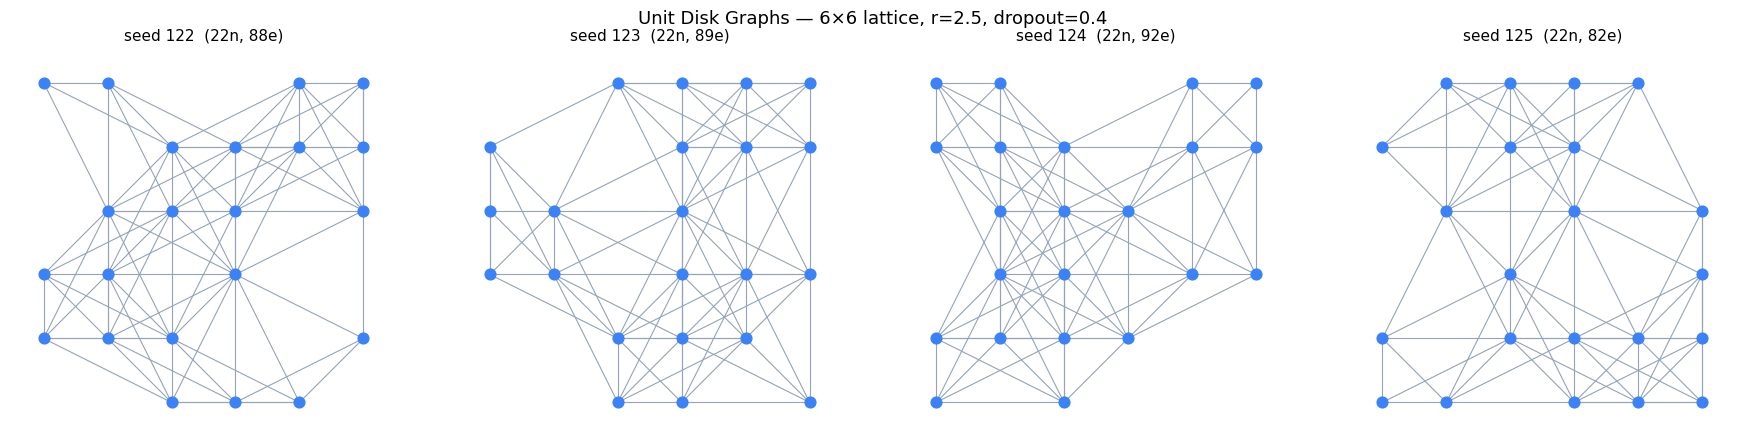

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, G, pos, s in zip(axes, graphs, positions, seeds):
    nx.draw(
        G, pos, ax=ax, with_labels=False,
        node_size=60, node_color="#3b82f6", edge_color="#94a3b8",
        width=0.8,
    )
    ax.set_title(f"seed {s}  ({G.number_of_nodes()}n, {G.number_of_edges()}e)", fontsize=11)
    ax.set_aspect("equal")
fig.suptitle(f"Unit Disk Graphs — {cfg.udg.nx}×{cfg.udg.ny} lattice, r={cfg.udg.radius}, dropout={cfg.udg.dropout_rate}", fontsize=13)
fig.tight_layout()
plt.show()

## Untrained SchedulePolicy predictions

In [15]:
torch.manual_seed(42)
policy = SchedulePolicy(cfg)
n_params = sum(p.numel() for p in policy.parameters())
print(f"Architecture {cfg.controls.architecture} — {n_params:,} parameters")
print(f"Omega head params: {policy.omega_head.n_params}")
print(f"Delta head params: {policy.delta_head.n_params}")
print(f"Total action dim:  {policy.omega_head.n_params + policy.delta_head.n_params}")

Architecture 1 — 46,932 parameters
Omega head params: 0
Delta head params: 8
Total action dim:  8


In [16]:
schedules = [policy.make_schedule(G) for G in graphs]

# The deltas ARE different — just by tiny amounts (untrained network)
for sched, s in zip(schedules, seeds):
    print(f"seed {s}: Δ mean={sched.delta.mean():+.4f}, "
          f"range=[{sched.delta.min():+.4f}, {sched.delta.max():+.4f}]")
print()
for i in range(len(schedules)):
    for j in range(i + 1, len(schedules)):
        diff = np.abs(schedules[i].delta - schedules[j].delta).max()
        print(f"  max |Δ_{seeds[i]} - Δ_{seeds[j]}| = {diff:.6f} rad/µs")

seed 122: Δ mean=+9.9995, range=[-24.9949, +25.0000]
seed 123: Δ mean=+10.0253, range=[-24.9947, +25.0000]
seed 124: Δ mean=+10.0288, range=[-24.9994, +25.0000]
seed 125: Δ mean=+10.0176, range=[-24.9395, +25.0000]

  max |Δ_122 - Δ_123| = 0.361826 rad/µs
  max |Δ_122 - Δ_124| = 0.232378 rad/µs
  max |Δ_122 - Δ_125| = 1.567413 rad/µs
  max |Δ_123 - Δ_124| = 0.387703 rad/µs
  max |Δ_123 - Δ_125| = 1.205587 rad/µs
  max |Δ_124 - Δ_125| = 1.593290 rad/µs


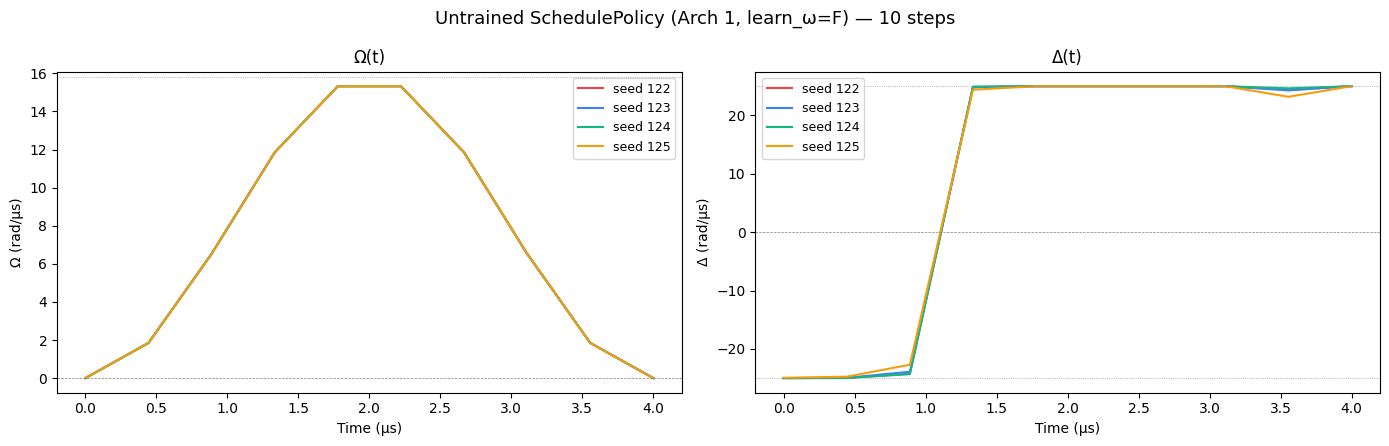

In [17]:
t_us = np.linspace(0, cfg.controls.T * 1e6, cfg.controls.N_t)
colors = ["#ef4444", "#3b82f6", "#10b981", "#f59e0b"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for sched, s, c in zip(schedules, seeds, colors):
    axes[0].plot(t_us, sched.omega, color=c, linewidth=1.5, label=f"seed {s}")
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].axhline(cfg.controls.omega_max, color="gray", linewidth=0.5, linestyle=":")
axes[0].set_ylabel("Ω (rad/µs)")
axes[0].set_xlabel("Time (µs)")
axes[0].set_title("Ω(t)")
axes[0].legend(fontsize=9)

for sched, s, c in zip(schedules, seeds, colors):
    axes[1].plot(t_us, sched.delta, color=c, linewidth=1.5, label=f"seed {s}")
axes[1].axhline(cfg.controls.delta_min, color="gray", linewidth=0.5, linestyle=":")
axes[1].axhline(cfg.controls.delta_max, color="gray", linewidth=0.5, linestyle=":")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Δ (rad/µs)")
axes[1].set_xlabel("Time (µs)")
axes[1].set_title("Δ(t)")
axes[1].legend(fontsize=9)

fig.suptitle(
    f"Untrained SchedulePolicy (Arch {cfg.controls.architecture}, "
    f"learn_ω={'T' if cfg.controls.learn_omega else 'F'}) — {cfg.controls.N_t} steps",
    fontsize=13,
)
fig.tight_layout()
plt.show()

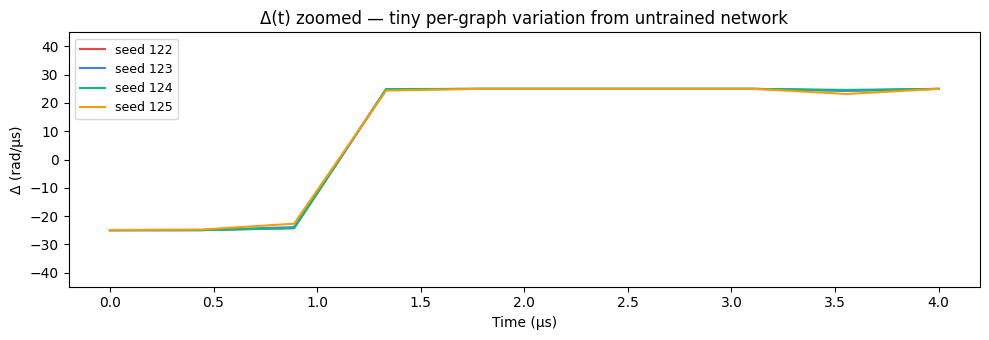

In [18]:
# Zoom into delta to reveal the per-graph variation
fig, ax = plt.subplots(figsize=(10, 3.5))
for sched, s, c in zip(schedules, seeds, colors):
    ax.plot(t_us, sched.delta, color=c, linewidth=1.5, label=f"seed {s}")
delta_all = np.stack([s.delta for s in schedules])
lo, hi = delta_all.min(), delta_all.max()
margin = max(0.05, (hi - lo) * 0.4)
ax.set_ylim(lo - margin, hi + margin)
ax.set_ylabel("Δ (rad/µs)")
ax.set_xlabel("Time (µs)")
ax.set_title("Δ(t) zoomed — tiny per-graph variation from untrained network")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()